In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.interpolate import griddata
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mplc
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
%matplotlib inline
import seaborn as sns
import random
import pyreadr
import requests
import re
import xarray as xr
import rasterio


# import descartes
import geopandas as gpd
import geodatasets
from shapely.geometry import Point, Polygon, LineString
import shapely.geometry
import osmnx as ox #openstreet map
import pickle

import folium

%matplotlib inline

import networkx as nx
import collections

import rioxarray

import netCDF4
from netCDF4 import num2date


import warnings
warnings.filterwarnings('ignore')


import os

In [3]:
#STEP RESOLUTION DEGREES TO meters

from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):

    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371000 # Radius of earth in meters
    return c * r 

haversine(10,10,10.01,10)

1095.0562585100474

# INFORMATION

In [4]:
temperature = 'mean'
PM = '25'
size = '1000'

# CITIES

In [5]:
# example with one city

cities = [
    'Barcelona'
]

# AIR TEMPERATURE - UrbClim

In [6]:
# Base folder where you want to store the datasets per city
base_output_dir = r"C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\TEMPERATURE\UrbClim_100m\datasets_GLOBAL"

T_dic = {}

for city in cities:
    # Create a city-specific output directory
    output_dir = os.path.join(base_output_dir, city)
    os.makedirs(output_dir, exist_ok=True)

    
    # -------------------------------
    # Stage 1: Download the UrbClim NetCDF File for the city
    # -------------------------------
    '''
    url = "https://provide.marvin.vito.be/ftp/compressed_daily/" + city + "/"
    
    response = requests.get(url)
    if response.status_code == 200:
        # Use regex to find all .nc file links in the directory listing
        file_links = re.findall(r'href="(.*?\.nc)"', response.text)
        print(f"{city}: Found files:", file_links)
        # We are interested in the file named "T2M_year_daily_mean_2017.nc"
        target_file = "T2M_year_daily_mean_2015.nc"
        if target_file in file_links:
            full_url = url + target_file
            print(f"{city}: Downloading {full_url}")
            file_response = requests.get(full_url)
            output_path = os.path.join(output_dir, target_file)
            with open(output_path, 'wb') as f:
                f.write(file_response.content)
            print(f"{city}: Downloaded and saved to {output_path}")
        else:
            print(f"{city}: {target_file} not found on the server.")
    else:
        print(f"{city}: Failed to fetch directory listing: {response.status_code}")
    '''
    # -------------------------------
    # Stage 2: Open and Process the NetCDF File
    # -------------------------------
    
    target_file = "T2M_year_daily_mean_2017.nc"
    
    nc_path = os.path.join(output_dir, target_file)
    ds = xr.open_dataset(nc_path)
    # Inspect the dataset if needed:
    # print(f"{city}: Dataset info:")
    # print(ds)
    
    # Reproject the data since crs is in local projection
    local_crs = ds.attrs.get("crs")
    # print(local_crs)
    ds['T2M'] = ds['T2M'].rio.write_crs(local_crs, inplace=False)
    
    tas_4326 = ds['T2M'].rio.reproject("EPSG:4326")
    
    # Compute the annual mean over time (average of all 365 days)
    annual_mean = tas_4326.mean(dim="time")
    
    # Convert the resulting DataArray to a DataFrame.
    df = annual_mean.to_dataframe(name="T").reset_index()
    if "longitude" in df.columns and "latitude" in df.columns:
        df = df.rename(columns={"longitude": "x", "latitude": "y"})
    
    # Store the DataFrame in the dictionary keyed by city
    T_dic[city] = df
    

# DEFINING CITY BOX

In [7]:
# based on the temperature data domain

xmin = {}
xmax = {}
ymin = {}
ymax = {}

for city in cities:
    
    xmin[city], ymin[city] = min(T_dic[city].x), min(T_dic[city].y) 
    xmax[city], ymax[city] = max(T_dic[city].x), max(T_dic[city].y)

# MAX LAND SURFACE TEMPERATURE (LST)

# STREET NETWORK

In [8]:
#OPEN STREET NETWORK

os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\street_network\dataframes')

net_type = 'drive'

NETWORK_node_dic = {}
pos_dic = {}

for city in cities:
    
    NETWORK = pickle.load(open(city+'_NETWORK_'+net_type, 'rb'))
    pos_ = {}
    
    for n in NETWORK.nodes:
        pos_[n] = [NETWORK.nodes('x')[n],NETWORK.nodes('y')[n]]
    pos_dic[city] = pos_

    pos_arr = np.array([pos_dic[city][x] for x in pos_dic[city].keys()])

    NETWORK_node_dic[city] = pd.DataFrame(index=list(range(len(pos_arr))),columns=['x','y'])

    NETWORK_node_dic[city].x = pos_arr[:,0]
    NETWORK_node_dic[city].y = pos_arr[:,1]
    NETWORK_node_dic[city]['node'] = 1

# POPULATION

In [9]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\population\city_geocode_popu_GLOBAL')

pop_dic = {}

xds = rioxarray.open_rasterio('ppp_2020_1Km_Aggregated.tif',masked=True) #Read tif doc

for city in cities:

    xdsc = xds.rio.clip_box(xmin[city],ymin[city],xmax[city],ymax[city])

    xdsc.name = "population"    
    xdsc = xdsc.squeeze().drop_vars("spatial_ref").drop_vars("band")
    
    pop_dic[city] = xdsc.to_dataframe().reset_index()

# PM 2.5

In [10]:
# GLOBAL DATA 

month = 'GHAP_PM2.5_Y1K_2022_V1.nc'
nc_path = r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\POLLUTION\PM25_GLOBAL\\' + month

ds = xr.open_dataset(nc_path)
da = ds['PM2.5']

def oslice(coord, a, b):
    c0, c1 = float(coord[0]), float(coord[-1])
    lo, hi = (min(a, b), max(a, b))
    if c0 <= c1:         # ascending coord
        return slice(lo, hi)
    else:                # descending coord
        return slice(hi, lo)

PM_dic = {}
for city in cities:
    pm25_city = da.sel(
        lon=oslice(da['lon'], xmin[city], xmax[city]),
        lat=oslice(da['lat'], ymin[city], ymax[city])
    )
    
    df = (pm25_city
          .to_dataframe(name="PM25")
          .reset_index()
          .rename(columns={'lon': 'x', 'lat': 'y'}))

    PM_dic[city] = df


# GEOPANDA OVERLAP

In [11]:
size = '1000'
cell_size_meters = 1000  # in m

## STREET NETWORK

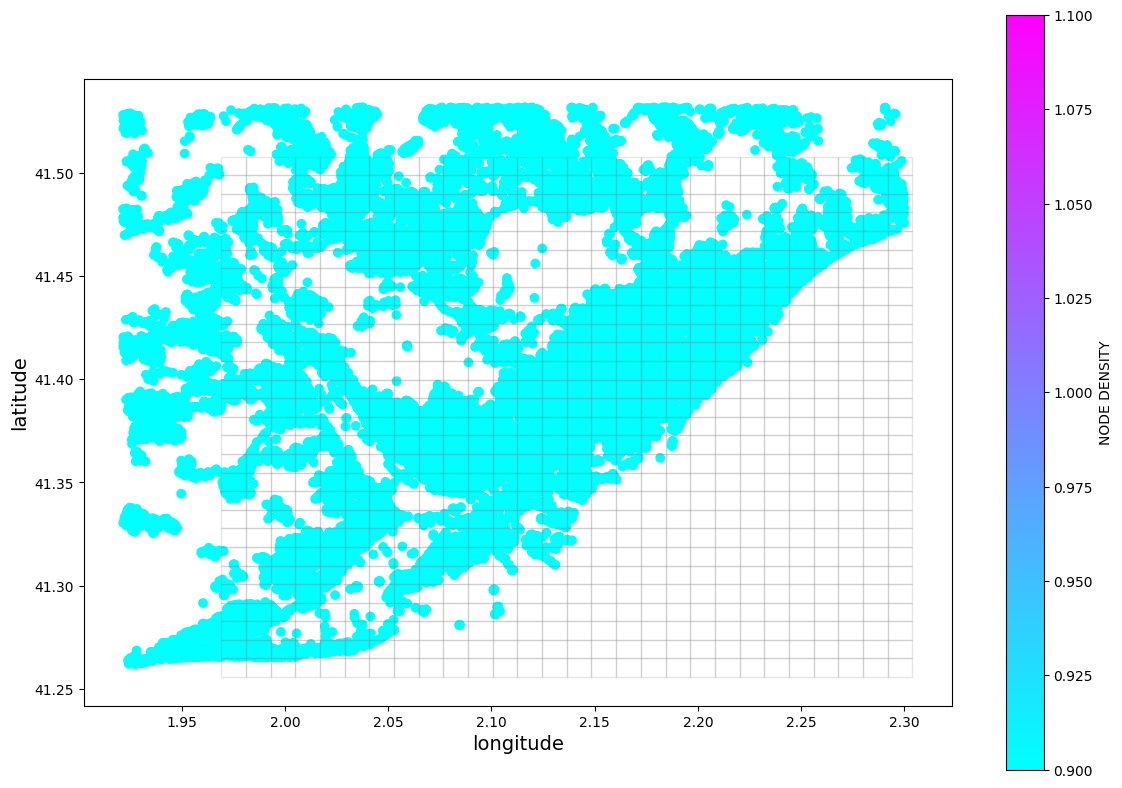

In [12]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\street_network') 

geo_NETWORK_node_dic = {}
merged_NETWORK_node_dic = {}

for city in cities:

    NETWORK_node_dic[city] = NETWORK_node_dic[city].dropna()

    fig, ax = plt.subplots(figsize=(14,14))

    geometry = [Point(xy) for xy in zip(NETWORK_node_dic[city]['x'], NETWORK_node_dic[city]['y'])]

    crs = {'init':'epsg:4326'}

    geo_NETWORK_node_dic[city] = gpd.GeoDataFrame(NETWORK_node_dic[city],
                              crs=crs, #specify our coordinate reference system
                              geometry=geometry)

    geo_NETWORK_node_dic[city] = geo_NETWORK_node_dic[city].drop(columns=['x', 'y'])

    geo_NETWORK_node_dic[city].plot(column = 'node', ax= ax, cmap='cool', legend = True, legend_kwds={"label": "NODE DENSITY", "shrink":.7})

    phi_deg = (ymin[city] + ymax[city]) / 2.0
    phi = np.radians(phi_deg)
    
    m_per_deg_lat = (111132.92
                     - 559.82*np.cos(2*phi)
                     +   1.175*np.cos(4*phi)
                     -   0.0023*np.cos(6*phi))
    
    m_per_deg_lon = (111412.84*np.cos(phi)
                     -    93.5*np.cos(3*phi)
                     +     0.118*np.cos(5*phi))
    
    cell_size_lat = cell_size_meters / m_per_deg_lat
    cell_size_lon = cell_size_meters / m_per_deg_lon
    
    n_cells_x = (xmax[city] - xmin[city]) / cell_size_lon
    n_cells_y = (ymax[city] - ymin[city]) / cell_size_lat
    
    # projection of the grid
    crs = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"
    # create cells
    grid_cells = []
    for y0 in np.arange(ymax[city], ymin[city], -cell_size_lat):
        for x0 in np.arange(xmin[city], xmax[city], cell_size_lon):
            # Bounds
            x1 = x0 + cell_size_lon
            y1 = y0 - cell_size_lat
            grid_cells.append(shapely.geometry.box(x0, y0, x1, y1))

    merged_NETWORK_node_dic[city] = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs=crs)
    
    merged_NETWORK_node_dic[city].plot(ax=ax, alpha = 0.2, facecolor="none", edgecolor='grey')

    ax.set_xlabel("longitude", fontsize = '14')
    ax.set_ylabel("latitude", fontsize = '14')

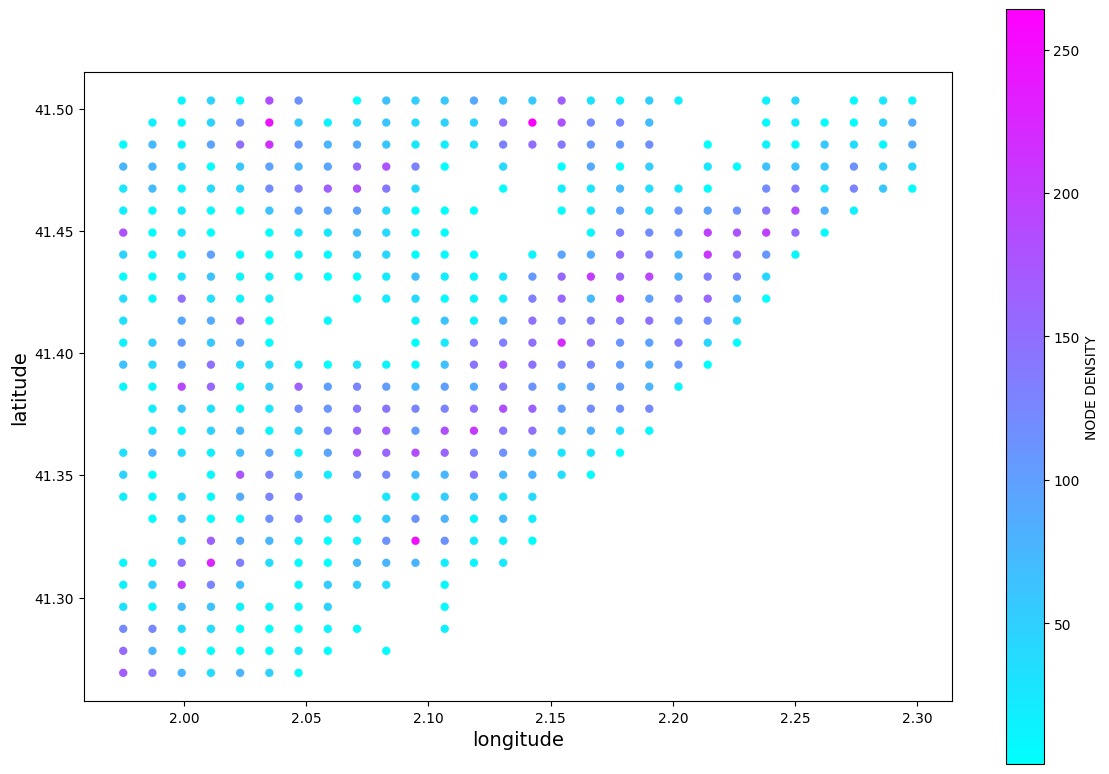

In [13]:
merged_node_dic = {}

for city in cities:
    
    merged_node_dic[city] = gpd.sjoin(geo_NETWORK_node_dic[city], merged_NETWORK_node_dic[city], how='left') #, op='within'

    # BASELINE 
    grouped = merged_node_dic[city].groupby('index_right')['node'].agg(['sum','count']) #'std', 'max','min','mean','sum', lambda x: np.nanmean(x)
    merged_NETWORK_node_dic[city]['node'] = grouped['sum']

    merged_NETWORK_node_dic[city]['geometry'] = merged_NETWORK_node_dic[city]['geometry'].centroid
    
    fig, ax = plt.subplots(figsize=(14,14))

    merged_NETWORK_node_dic[city].plot(ax= ax, column = 'node',alpha=1, linewidth=0, cmap='cool', legend = True, legend_kwds={"label": "NODE DENSITY", "shrink":.7})

    ax.set_xlabel("longitude", fontsize = '14')
    ax.set_ylabel("latitude", fontsize = '14')

In [14]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS')

for city in cities:
    merged_NETWORK_node_dic[city]['x'] = merged_NETWORK_node_dic[city]['geometry'].x
    merged_NETWORK_node_dic[city]['y'] = merged_NETWORK_node_dic[city]['geometry'].y

Barcelona


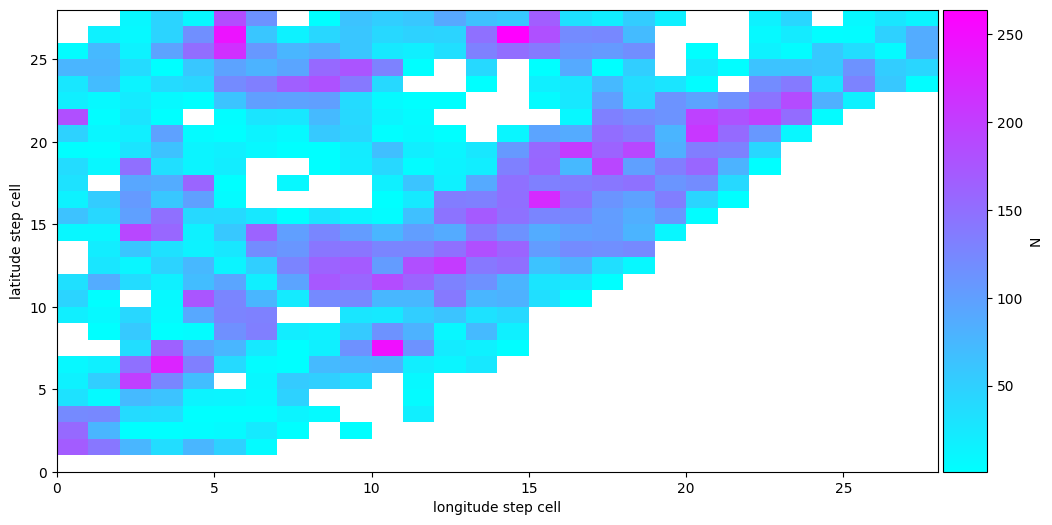

In [15]:
NODEs_dic = {}

for city in cities:

    print(city)
    
    NODEs_dic[city] = merged_NETWORK_node_dic[city]['node']

    merged_NETWORK_node_dic[city]['x'] = merged_NETWORK_node_dic[city]['x'].round(decimals=10)
    merged_NETWORK_node_dic[city]['y'] = merged_NETWORK_node_dic[city]['y'].round(decimals=10)

    total_lat = len(pd.unique(merged_NETWORK_node_dic[city]['y']))
    total_lon = len(pd.unique(merged_NETWORK_node_dic[city]['x']))

    fig, ax = plt.subplots(figsize=(12, 6))

    NODEs_dic[city] = np.reshape(NODEs_dic[city], (total_lat, total_lon))

    NODEs_dic[city] = np.flipud(NODEs_dic[city])

    x = np.linspace(0, total_lon, total_lon + 1)
    y = np.linspace(0, total_lat, total_lat + 1)

    im = ax.pcolormesh(x, y, NODEs_dic[city], cmap='cool', shading='auto')

    plt.xlabel('longitude step cell')
    plt.ylabel('latitude step cell')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, label='N', cax=cax)
    
    # plt.savefig(city + '_NODE_heatmap_'+size+'.svg', dpi=1200, bbox_inches="tight")
    
    plt.show()

Barcelona


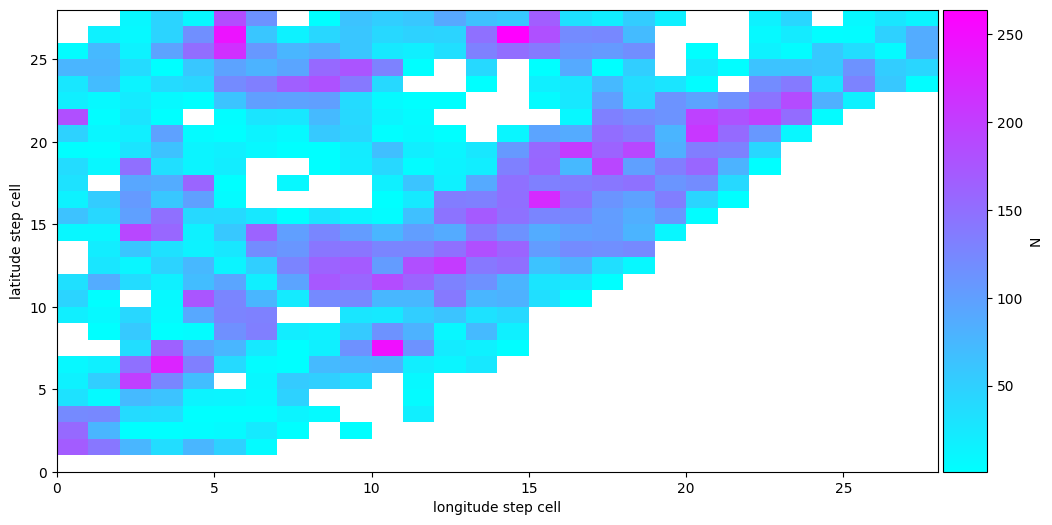

In [16]:
NODEs_dic = {}

for city in cities:

    print(city)
    
    NODEs_dic[city] = merged_NETWORK_node_dic[city]['node']

    merged_NETWORK_node_dic[city]['x'] = merged_NETWORK_node_dic[city]['x'].round(decimals=10)
    merged_NETWORK_node_dic[city]['y'] = merged_NETWORK_node_dic[city]['y'].round(decimals=10)

    total_lat = len(pd.unique(merged_NETWORK_node_dic[city]['y']))
    total_lon = len(pd.unique(merged_NETWORK_node_dic[city]['x']))

    fig, ax = plt.subplots(figsize=(12, 6))

    NODEs_dic[city] = np.reshape(NODEs_dic[city], (total_lat, total_lon))

    NODEs_dic[city] = np.flipud(NODEs_dic[city])

    x = np.linspace(0, total_lon, total_lon + 1)
    y = np.linspace(0, total_lat, total_lat + 1)

    im = ax.pcolormesh(x, y, NODEs_dic[city], cmap='cool', shading='auto')

    plt.xlabel('longitude step cell')
    plt.ylabel('latitude step cell')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, label='N', cax=cax)
    
    # plt.savefig(city + '_NODE_heatmap_'+size+'.svg', dpi=1200, bbox_inches="tight")
    
    plt.show()

## POPULATION

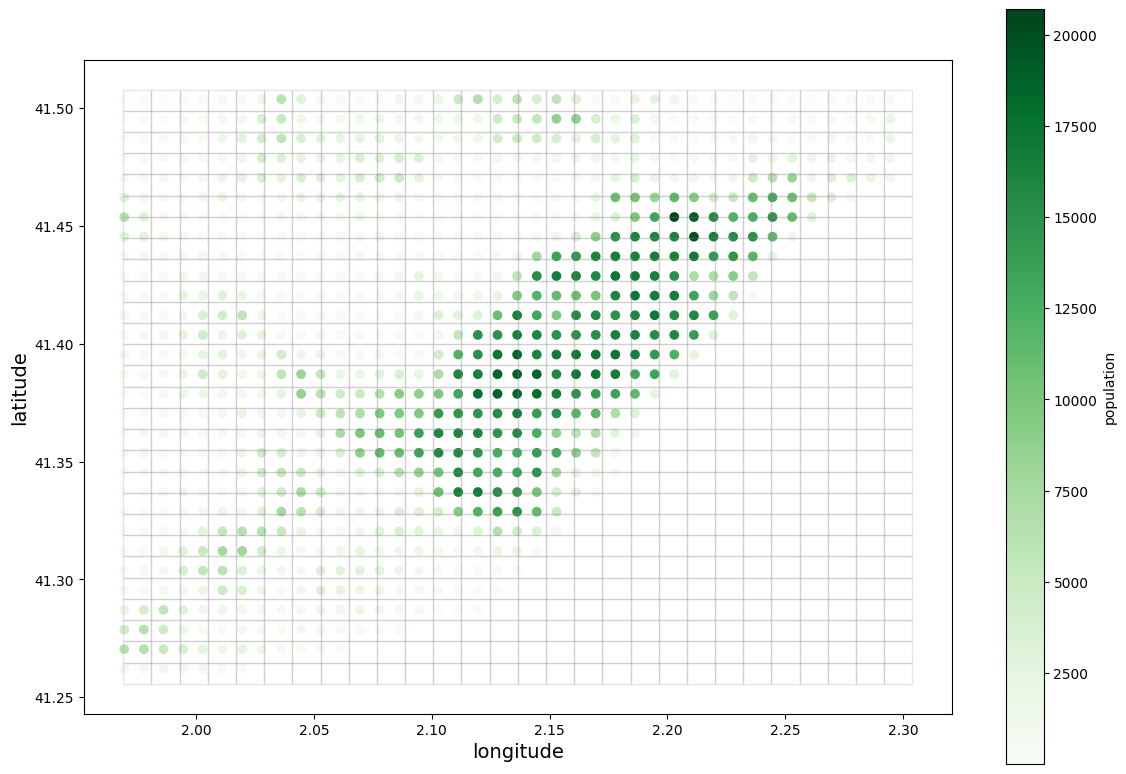

In [17]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs') 

geo_pop_dic = {}
merged_pop_dic = {}

for city in cities:
    
    pop_dic[city] = pop_dic[city].dropna()

    fig, ax = plt.subplots(figsize=(14,14))

    geometry = [Point(xy) for xy in zip(pop_dic[city]['x'], pop_dic[city]['y'])]

    crs = {'init':'epsg:4326'}

    geo_pop_dic[city] = gpd.GeoDataFrame(pop_dic[city], #specify our data
                              crs=crs, #specify our coordinate reference system
                              geometry=geometry) #specify the geometry list we created

    geo_pop_dic[city] = geo_pop_dic[city].drop(columns=['x', 'y'])

    geo_pop_dic[city].plot(column = 'population', ax= ax, cmap='Greens', legend = True, legend_kwds={"label": "population", "shrink":.7})


    phi_deg = (ymin[city] + ymax[city]) / 2.0       
    phi = np.radians(phi_deg)
    
    m_per_deg_lat = (111132.92
                     - 559.82*np.cos(2*phi)
                     +   1.175*np.cos(4*phi)
                     -   0.0023*np.cos(6*phi))
    
    m_per_deg_lon = (111412.84*np.cos(phi)
                     -    93.5*np.cos(3*phi)
                     +     0.118*np.cos(5*phi))
    
    cell_size_lat = cell_size_meters / m_per_deg_lat
    cell_size_lon = cell_size_meters / m_per_deg_lon
    
    n_cells_x = (xmax[city] - xmin[city]) / cell_size_lon
    n_cells_y = (ymax[city] - ymin[city]) / cell_size_lat
    
    # projection of the grid
    crs = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"
    # create the cells
    grid_cells = []
    for y0 in np.arange(ymax[city], ymin[city], -cell_size_lat): #cell_size_temperature
        for x0 in np.arange(xmin[city], xmax[city], cell_size_lon):
            # Bounds
            x1 = x0 + cell_size_lon
            y1 = y0 - cell_size_lat
            grid_cells.append(shapely.geometry.box(x0, y0, x1, y1))

    merged_pop_dic[city] = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs=crs)
    
    merged_pop_dic[city].plot(ax=ax, alpha = 0.2, facecolor="none", edgecolor='grey')

    ax.set_xlabel("longitude", fontsize = '14')
    ax.set_ylabel("latitude", fontsize = '14')

    # plt.savefig(city+'_pop_geo_grid100.svg', format='svg', dpi=1200)

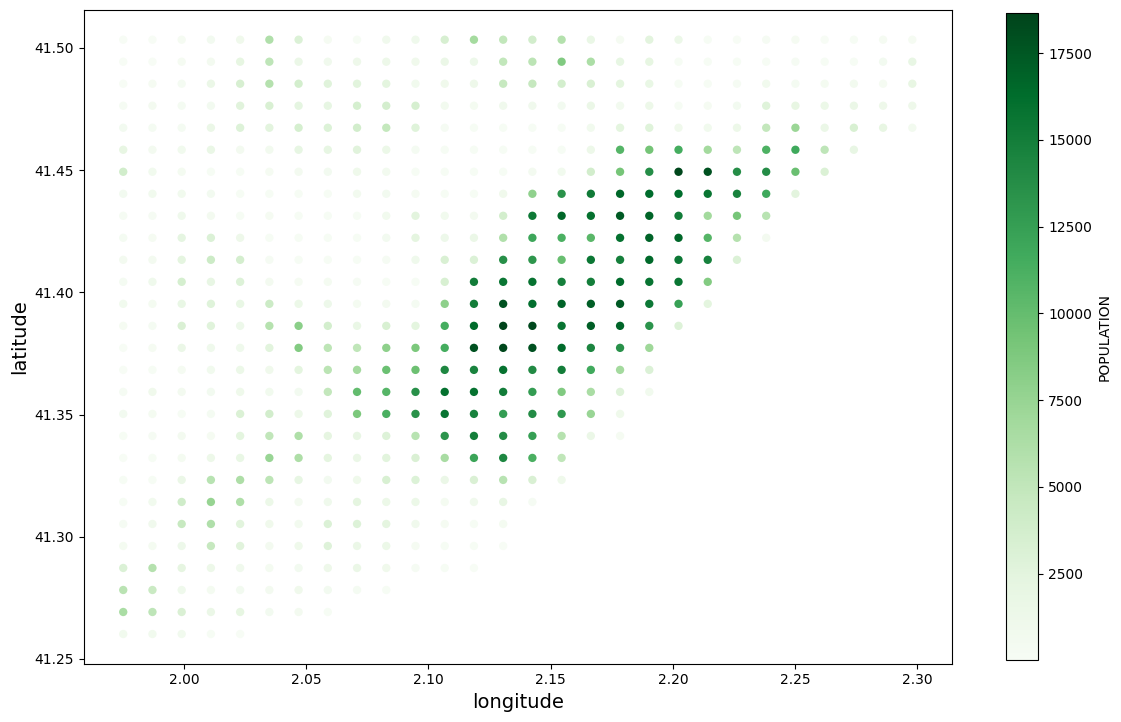

In [18]:

merged_dic = {}

for city in cities:
    
    merged_dic[city] = gpd.sjoin(geo_pop_dic[city], merged_pop_dic[city], how='inner') 
    
    grouped = merged_dic[city].groupby('index_right')['population'].agg(['mean','count']) 
    merged_pop_dic[city]['population'] = grouped['mean']


    merged_pop_dic[city]['geometry'] = merged_pop_dic[city]['geometry'].centroid
    
    fig, ax = plt.subplots(figsize=(14,14))

    merged_pop_dic[city].plot(ax= ax, column = 'population',alpha=1, linewidth=0, cmap='Greens', legend = True, legend_kwds={"label": "POPULATION", "shrink":.6})

    ax.set_xlabel("longitude", fontsize = '14')
    ax.set_ylabel("latitude", fontsize = '14')

    plt.show()

In [19]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS')

for city in cities:
    merged_pop_dic[city]['x'] = merged_pop_dic[city]['geometry'].x
    merged_pop_dic[city]['y'] = merged_pop_dic[city]['geometry'].y

Barcelona


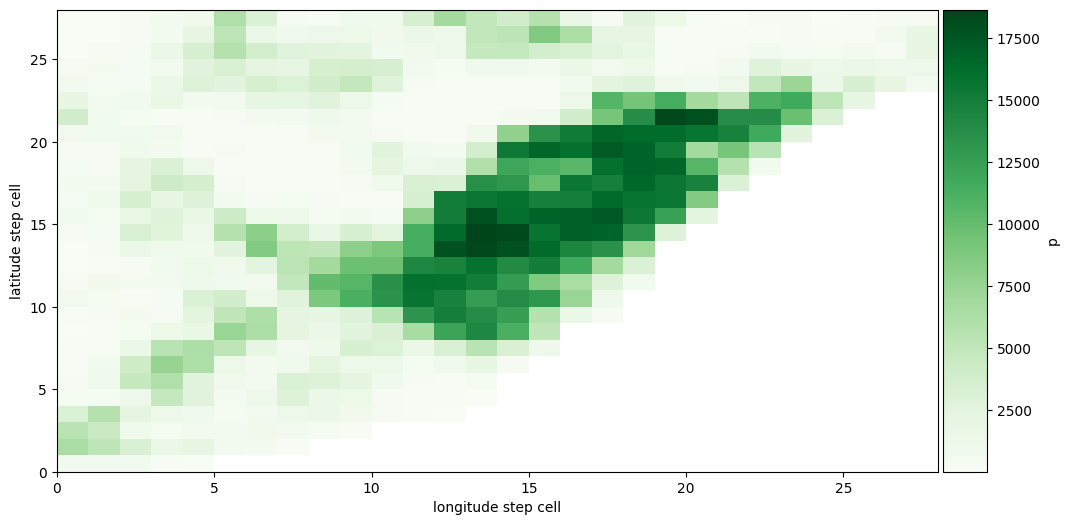

In [21]:

population_dic = {}

for city in cities:

    print(city)
    
    population_dic[city] = merged_pop_dic[city]['population']

    merged_pop_dic[city]['x'] = merged_pop_dic[city]['x'].round(decimals=10)
    merged_pop_dic[city]['y'] = merged_pop_dic[city]['y'].round(decimals=10)

    total_lat = len(pd.unique(merged_pop_dic[city]['y']))
    total_lon = len(pd.unique(merged_pop_dic[city]['x']))

    fig, ax = plt.subplots(figsize=(12, 6))

    population_dic[city] = np.reshape(population_dic[city], (total_lat, total_lon))

    population_dic[city] = np.flipud(population_dic[city])

    x = np.linspace(0, total_lon, total_lon + 1)
    y = np.linspace(0, total_lat, total_lat + 1)

    im = ax.pcolormesh(x, y, population_dic[city], cmap='Greens', shading='auto') 

    plt.xlabel('longitude step cell')
    plt.ylabel('latitude step cell')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, label='p', cax=cax)
        
    plt.show()

## TEMPERATURE

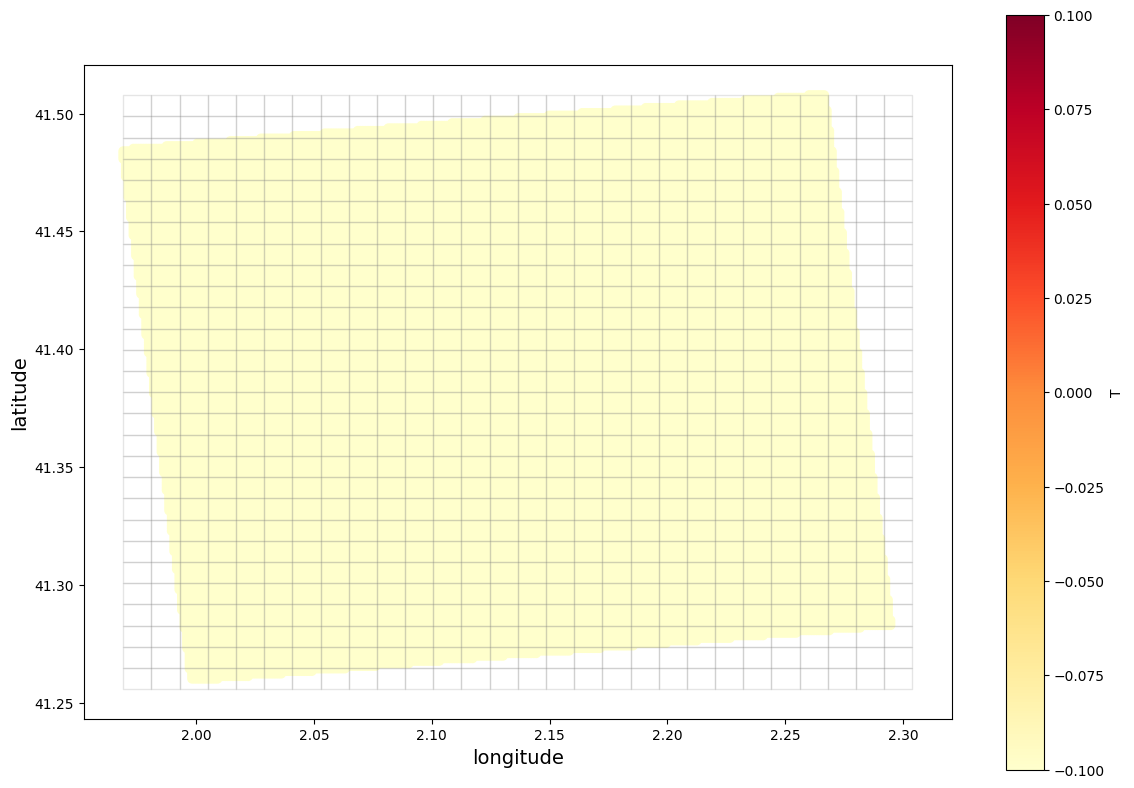

In [22]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS\DEF_AIRT_ALL')

geo_T_dic = {}
merged_T_dic = {}

for city in cities:

    T_dic[city] = T_dic[city].dropna()

    fig, ax = plt.subplots(figsize=(14,14))

    geometry = [Point(xy) for xy in zip(T_dic[city]['x'], T_dic[city]['y'])]

    crs = {'init':'epsg:4326'}

    geo_T_dic[city] = gpd.GeoDataFrame(T_dic[city],
                              crs=crs, #specify our coordinate reference system
                              geometry=geometry)

    geo_T_dic[city] = geo_T_dic[city].drop(columns=['x', 'y'])

    geo_T_dic[city].plot(column = 'T', ax= ax, cmap='YlOrRd', legend = True, legend_kwds={"label": "T", "shrink":.7})


    phi_deg = (ymin[city] + ymax[city]) / 2.0 
    phi = np.radians(phi_deg)
    
    m_per_deg_lat = (111132.92
                     - 559.82*np.cos(2*phi)
                     +   1.175*np.cos(4*phi)
                     -   0.0023*np.cos(6*phi))
    
    m_per_deg_lon = (111412.84*np.cos(phi)
                     -    93.5*np.cos(3*phi)
                     +     0.118*np.cos(5*phi))
    
    cell_size_lat = cell_size_meters / m_per_deg_lat
    cell_size_lon = cell_size_meters / m_per_deg_lon
    
    n_cells_x = (xmax[city] - xmin[city]) / cell_size_lon
    n_cells_y = (ymax[city] - ymin[city]) / cell_size_lat
    
    # projection of the grid
    crs = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"
    # create the cells
    grid_cells = []
    for y0 in np.arange(ymax[city], ymin[city], -cell_size_lat): 
        for x0 in np.arange(xmin[city], xmax[city], cell_size_lon):
            # Bounds
            x1 = x0 + cell_size_lon
            y1 = y0 - cell_size_lat
            grid_cells.append(shapely.geometry.box(x0, y0, x1, y1, ccw=True))

    merged_T_dic[city] = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs=crs)
    
    merged_T_dic[city].plot(ax=ax, alpha = 0.2, facecolor="none", edgecolor='grey')


    ax.set_xlabel("longitude", fontsize = '14')
    ax.set_ylabel("latitude", fontsize = '14')

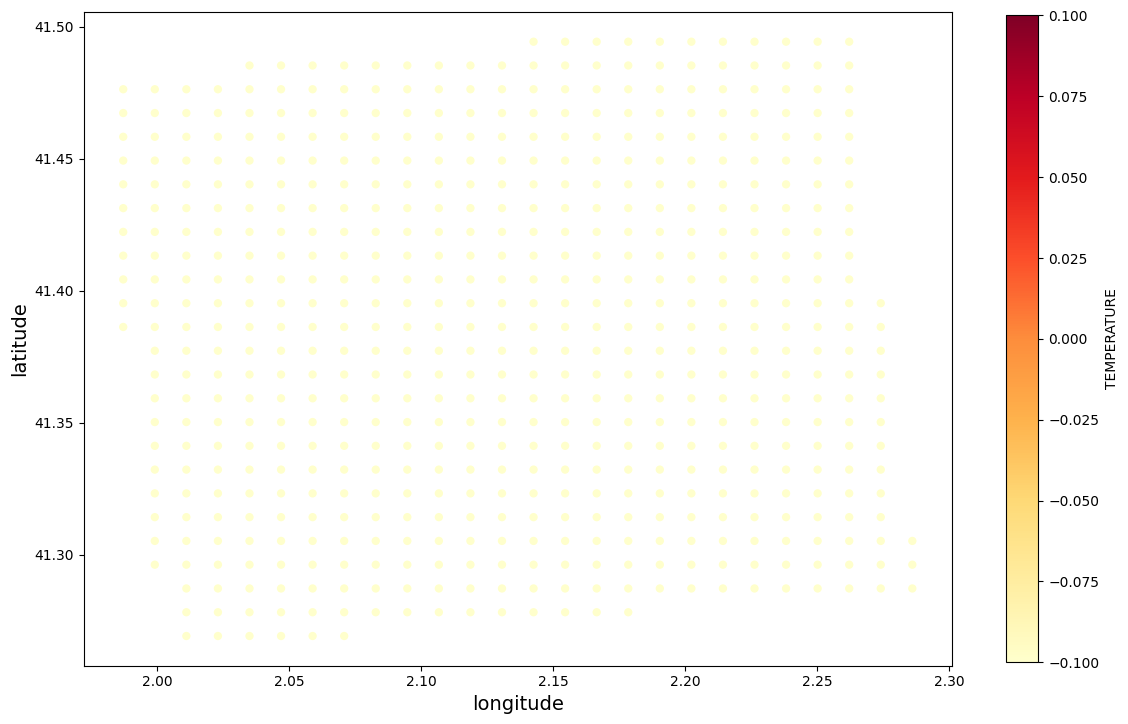

In [23]:
merged_dic = {}

for city in cities:
    
    merged_dic[city] = gpd.sjoin(geo_T_dic[city], merged_T_dic[city], how='left') 

    # BASELINE
    grouped_T = merged_dic[city].groupby('index_right')['T'].agg(['mean','count']) 
    merged_T_dic[city]['T'] = grouped_T['mean']

    
    merged_T_dic[city]['geometry'] = merged_T_dic[city]['geometry'].centroid
    
    fig, ax = plt.subplots(figsize=(14,14))

    merged_T_dic[city].plot(ax= ax, column = 'T',alpha=1, linewidth=0, cmap='YlOrRd', legend = True, legend_kwds={"label": "TEMPERATURE", "shrink":.6})

    ax.set_xlabel("longitude", fontsize = '14')
    ax.set_ylabel("latitude", fontsize = '14')

    plt.show()

In [24]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS')

for city in cities:
    merged_T_dic[city]['x'] = merged_T_dic[city]['geometry'].x
    merged_T_dic[city]['y'] = merged_T_dic[city]['geometry'].y

Barcelona


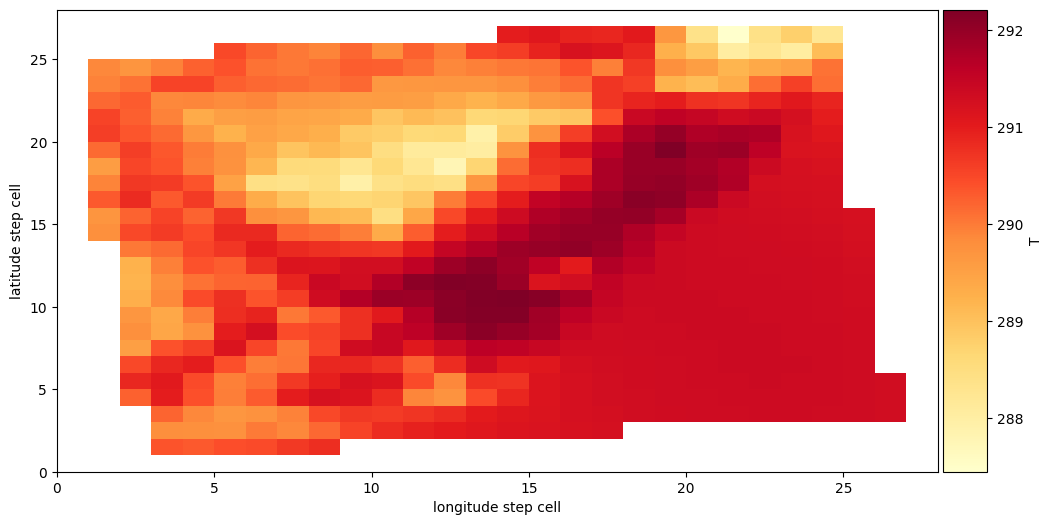

In [25]:
temperature_dic = {}

all_temperatures = np.concatenate([merged_T_dic[city]['T'].dropna().values for city in cities])

vmin = np.min(all_temperatures)
vmax = np.max(all_temperatures)
    

for city in cities:

    print(city)
    
    temperature_dic[city] = merged_T_dic[city]['T']

    merged_T_dic[city]['x'] = merged_T_dic[city]['x'].round(decimals=10)
    merged_T_dic[city]['y'] = merged_T_dic[city]['y'].round(decimals=10)

    total_lat = len(pd.unique(merged_T_dic[city]['y']))
    total_lon = len(pd.unique(merged_T_dic[city]['x']))

    fig, ax = plt.subplots(figsize=(12, 6))

    temperature_dic[city] = np.reshape(temperature_dic[city], (total_lat, total_lon))

    temperature_dic[city] = np.flipud(temperature_dic[city])

    x = np.linspace(0, total_lon, total_lon + 1)
    y = np.linspace(0, total_lat, total_lat + 1)

    # Replace imshow with pcolormesh
    im = ax.pcolormesh(x, y, temperature_dic[city], cmap='YlOrRd', shading='auto') 

    plt.xlabel('longitude step cell')
    plt.ylabel('latitude step cell')

    # Add colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, label='T', cax=cax)

    plt.show()

## PM 2.5

Barcelona


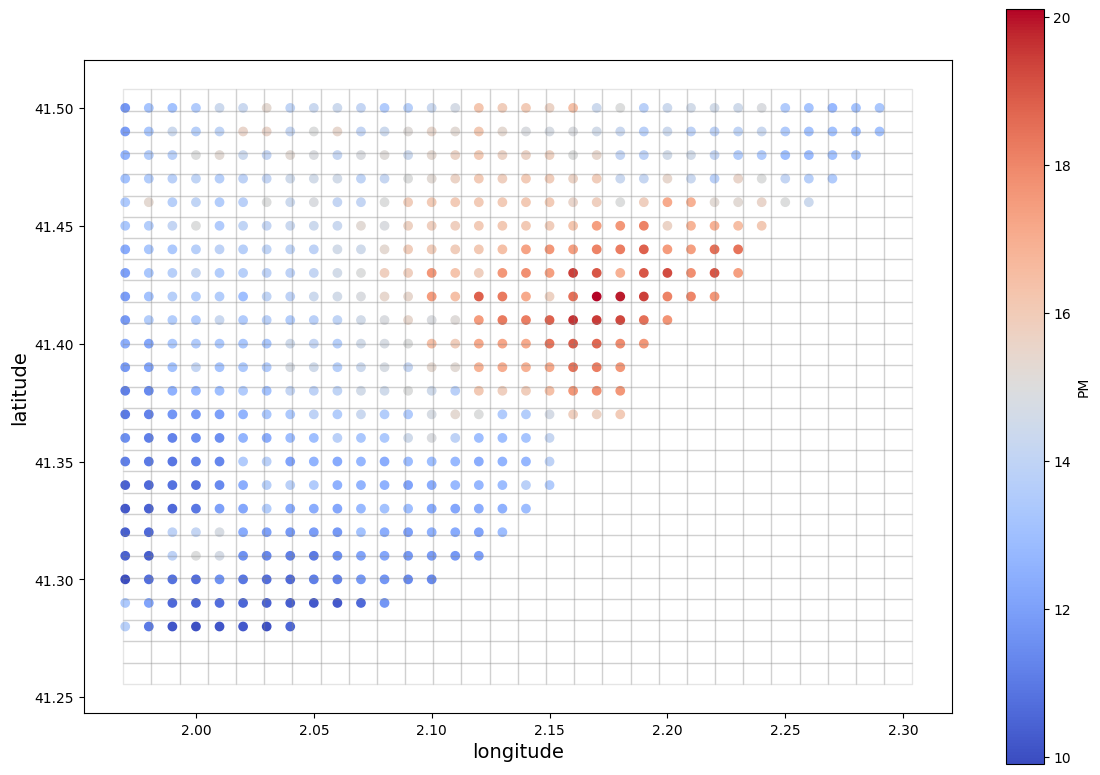

In [26]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs') 

PM = '25'

geo_PM_dic = {}
merged_PM_dic = {}

for city in cities:


    PM_dic[city] = PM_dic[city].dropna()

    fig, ax = plt.subplots(figsize=(14,14))

    geometry = [Point(xy) for xy in zip(PM_dic[city]['x'], PM_dic[city]['y'])]

    crs = {'init':'epsg:4326'}

    geo_PM_dic[city] = gpd.GeoDataFrame(PM_dic[city], 
                              crs=crs, #specify our coordinate reference system
                              geometry=geometry)

    geo_PM_dic[city] = geo_PM_dic[city].drop(columns=['x', 'y'])

    geo_PM_dic[city].plot(column = 'PM'+PM, ax= ax, cmap='coolwarm', legend = True, legend_kwds={"label": "PM", "shrink":.7})

    phi_deg = (ymin[city] + ymax[city]) / 2.0
    phi = np.radians(phi_deg)
    
    m_per_deg_lat = (111132.92
                     - 559.82*np.cos(2*phi)
                     +   1.175*np.cos(4*phi)
                     -   0.0023*np.cos(6*phi))
    
    m_per_deg_lon = (111412.84*np.cos(phi)
                     -    93.5*np.cos(3*phi)
                     +     0.118*np.cos(5*phi))
    
    cell_size_lat = cell_size_meters / m_per_deg_lat
    cell_size_lon = cell_size_meters / m_per_deg_lon
    
    n_cells_x = (xmax[city] - xmin[city]) / cell_size_lon
    n_cells_y = (ymax[city] - ymin[city]) / cell_size_lat
    
    # projection of the grid
    crs = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"
    # create the cells
    grid_cells = []
    for y0 in np.arange(ymax[city], ymin[city], -cell_size_lat): #cell_size_temperature
        for x0 in np.arange(xmin[city], xmax[city], cell_size_lon):
            # Bounds
            x1 = x0 + cell_size_lon
            y1 = y0 - cell_size_lat
            grid_cells.append(shapely.geometry.box(x0, y0, x1, y1))

    merged_PM_dic[city] = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs=crs)

    print(city)
    merged_PM_dic[city].plot(ax=ax, alpha = 0.2, facecolor="none", edgecolor='grey')

    ax.set_xlabel("longitude", fontsize = '14')
    ax.set_ylabel("latitude", fontsize = '14')
    plt.show()

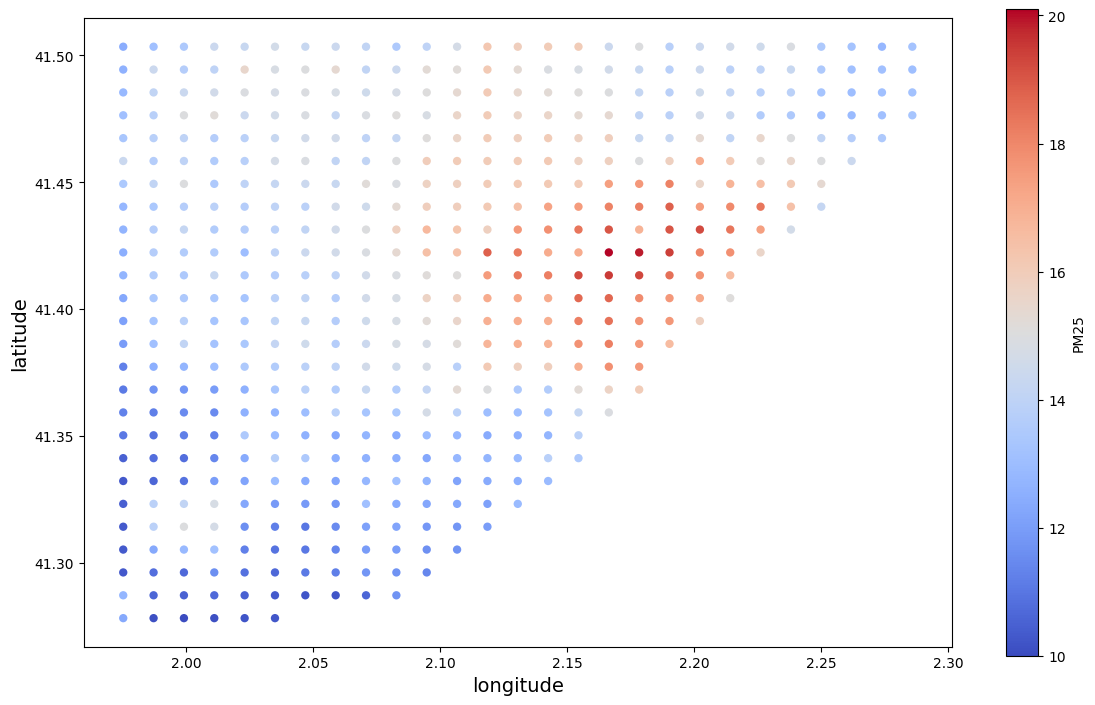

In [27]:
merged_dic = {}

for city in cities:
    
    merged_dic[city] = gpd.sjoin(geo_PM_dic[city], merged_PM_dic[city], how='left')
    
    grouped = merged_dic[city].groupby('index_right')['PM'+PM].agg(['mean','count']) 
    merged_PM_dic[city]['PM'+PM] = grouped['mean']

    merged_PM_dic[city]['geometry'] = merged_PM_dic[city]['geometry'].centroid


    # INTERPOLATION
    # Extract centroid coordinates and PM values
    grid_coords = np.array([(geom.centroid.x, geom.centroid.y) for geom in  merged_PM_dic[city].geometry])
    pm_values = merged_PM_dic[city]['PM'+PM].values

    # Identify valid and missing data
    valid_mask = ~np.isnan(pm_values)
    missing_mask = np.isnan(pm_values)

    if np.any(missing_mask):
        # Perform interpolation using griddata
        interpolated_values = griddata(
            points=grid_coords[valid_mask],
            values=pm_values[valid_mask],
            xi=grid_coords[missing_mask],
            method='linear'
        )

        # Assign interpolated values to missing cells
        merged_PM_dic[city].loc[missing_mask, 'PM'+PM] = interpolated_values

        still_missing = merged_PM_dic[city]['PM'+PM].isna()
        if still_missing.any():
            interpolated_nearest = griddata(
                points=grid_coords[valid_mask],
                values=pm_values[valid_mask],
                xi=grid_coords[still_missing],
                method='linear'#'nearest'
            )
            merged_PM_dic[city].loc[still_missing, 'PM'+PM] = interpolated_nearest
    
    fig, ax = plt.subplots(figsize=(14,14))

    merged_PM_dic[city].plot(ax= ax, column = 'PM'+PM,alpha=1, linewidth=0, cmap='coolwarm', legend = True, legend_kwds={"label": "PM"+PM, "shrink":.6})

    ax.set_xlabel("longitude", fontsize = '14')
    ax.set_ylabel("latitude", fontsize = '14')

    plt.show()


In [28]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS')

for city in cities:
    merged_PM_dic[city]['x'] = merged_PM_dic[city]['geometry'].x
    merged_PM_dic[city]['y'] = merged_PM_dic[city]['geometry'].y

Barcelona


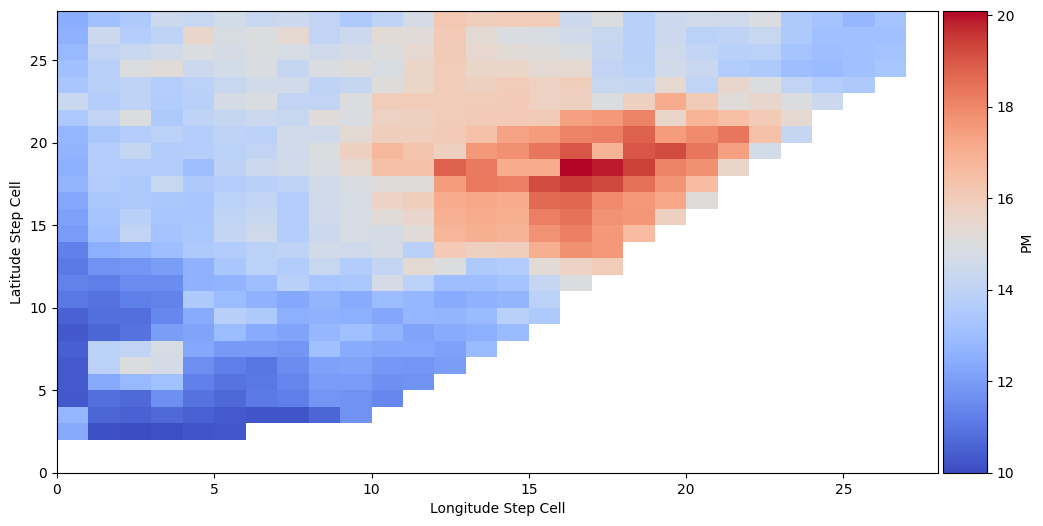

In [29]:
pollution_dic = {}

for city in cities:

    print(city)
    
    pollution_dic[city] = merged_PM_dic[city]['PM' + PM]
    
    merged_PM_dic[city]['x'] = merged_PM_dic[city]['x'].round(decimals=10)
    merged_PM_dic[city]['y'] = merged_PM_dic[city]['y'].round(decimals=10)
    
    total_lat = len(pd.unique(merged_PM_dic[city]['y']))
    total_lon = len(pd.unique(merged_PM_dic[city]['x']))
    
    fig, ax = plt.subplots(figsize=(12, 6))

    pollution_dic[city] = np.reshape(pollution_dic[city], (total_lat, total_lon))

    pollution_dic[city] = np.flipud(pollution_dic[city])
    
    x = np.linspace(0, total_lon, total_lon + 1)
    y = np.linspace(0, total_lat, total_lat + 1)
    
    im = ax.pcolormesh(x, y, pollution_dic[city], cmap='coolwarm', shading='auto')
    
    plt.xlabel('Longitude Step Cell')
    plt.ylabel('Latitude Step Cell')
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, label='PM', cax=cax)

    plt.show()

# GENERATE STREET NETWORK, POPULATION WITH CLIMATE VARIABLES

In [30]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS_GLOBAL') 

for city in cities:
    merged_pop_dic[city] = merged_pop_dic[city].drop(columns=['geometry'])
    merged_PM_dic[city] = merged_PM_dic[city].drop(columns=['geometry'])
    merged_T_dic[city] = merged_T_dic[city].drop(columns=['geometry'])
    merged_NETWORK_node_dic[city] = merged_NETWORK_node_dic[city].drop(columns=['geometry'])
    
    merged_PM_dic[city] = merged_PM_dic[city].drop(columns=['x'])
    merged_T_dic[city] = merged_T_dic[city].drop(columns=['x'])
    merged_NETWORK_node_dic[city] = merged_NETWORK_node_dic[city].drop(columns=['x'])

    merged_PM_dic[city] = merged_PM_dic[city].drop(columns=['y'])
    merged_T_dic[city] = merged_T_dic[city].drop(columns=['y'])
    merged_NETWORK_node_dic[city] = merged_NETWORK_node_dic[city].drop(columns=['y'])
    
    merged_pop_dic[city] = merged_pop_dic[city].reset_index(drop=True)
    merged_PM_dic[city] = merged_PM_dic[city].reset_index(drop=True)
    merged_T_dic[city] = merged_T_dic[city].reset_index(drop=True)
    merged_NETWORK_node_dic[city] = merged_NETWORK_node_dic[city].reset_index(drop=True)

In [31]:
# MERGE T AND POPULATION 

os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS_GLOBAL') 

T_PM_dic = {}
T_PM_NETWORK_dic = {}
pop_T_PM_NETWORK_dic = {}


for city in cities:
    T_PM_dic[city] = pd.concat([merged_T_dic[city], merged_PM_dic[city]], axis=1)
    T_PM_NETWORK_dic[city] = pd.concat([T_PM_dic[city], merged_NETWORK_node_dic[city]], axis=1)
    pop_T_PM_NETWORK_dic[city] = pd.concat([T_PM_NETWORK_dic[city], merged_pop_dic[city]], axis=1) 
    
    # pop_T_PM_NETWORK_dic[city].to_csv(city+'_pop_T'+temperature+'_PM'+PM+'_NETWORK_'+size+'.csv', index=False)

In [32]:
for city in cities:

    pop_T_PM_NETWORK_dic[city].replace([np.inf, -np.inf], np.nan, inplace=True)

    pop_T_PM_NETWORK_dic[city] = pop_T_PM_NETWORK_dic[city].dropna().reset_index(drop=True) 

In [33]:
pop_T_PM_NETWORK_dic[city]

,T,PM25,node,population,x,y
0,290.988436,14.900001,264.0,5374.654297,2.142503,41.494326
1,291.087243,14.850000,181.0,8608.199219,2.154459,41.494326
2,290.908832,14.600000,121.0,6275.921387,2.166414,41.494326
3,290.878763,14.300000,124.0,2099.753662,2.178369,41.494326
4,291.017543,13.800000,71.0,2134.510986,2.190325,41.494326
...,...,...,...,...,...,...
364,289.937377,10.200000,13.0,1184.171143,2.058816,41.287233
365,290.494076,10.600000,7.0,1605.317139,2.070772,41.287233
366,289.795965,10.100000,1.0,449.449890,2.010995,41.278229
367,289.785022,10.200000,4.0,631.656860,2.022950,41.278229
